In [1]:
# ============================================================================
# NOTEBOOK 01: EXPLORATORY DATA ANALYSIS - PARULIDAE ABUNDANCE & NICHE
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [2]:
# LOAD DATA
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

try:
    abundance_db = pd.read_csv('../data/raw/abundance_db.csv')
    print(f"✓ abundance_db.csv loaded: {abundance_db.shape}")
    
    presence_record = pd.read_csv('../data/raw/presence_records.csv')
    print(f"✓ presence_record.csv loaded: {presence_record.shape}")
    
    input_pgls = pd.read_csv('../data/raw/input_pgls.csv')
    print(f"✓ input_pgls.csv loaded: {input_pgls.shape}")
    
    input_presences_omi = pd.read_csv('../data/raw/input_presences_OMI.csv')
    print(f"✓ input_presences_OMI.csv loaded: {input_presences_omi.shape}")
    
except FileNotFoundError as e:
    print(f"❌ Error: {e}")


LOADING DATA
✓ abundance_db.csv loaded: (47786, 11)
✓ presence_record.csv loaded: (3825471, 23)
✓ input_pgls.csv loaded: (47, 17)
✓ input_presences_OMI.csv loaded: (81393, 47)


In [3]:
# ABUNDANCE DATA
print("\n" + "="*60)
print("ABUNDANCE DATA")
print("="*60)

print(f"\nShape: {abundance_db.shape}")
print(f"\nFirst rows:")
print(abundance_db.head())

print(f"\nColumns: {abundance_db.columns.tolist()}")
print(f"\nData types:")
print(abundance_db.dtypes)

print(f"\nMissing values: {abundance_db.isnull().sum().sum()}")


ABUNDANCE DATA

Shape: (47786, 11)

First rows:
    AOU        Scientific_name cod.concatenado  promedio_ruta  Latitude  \
0  6860  Cardellina_canadensis      124_11_110       3.000000  54.13311   
1  6860  Cardellina_canadensis      124_11_185       2.000000  54.76609   
2  6860  Cardellina_canadensis       124_11_84       1.000000  54.75011   
3  6860  Cardellina_canadensis       124_11_85       1.000000  55.48600   
4  6860  Cardellina_canadensis       124_4_149       1.333333  55.49903   

   Longitude          Order     Family       Genus     Species  n.x.ruta.n  
0 -116.21592  Passeriformes  Parulidae  Cardellina  canadensis           2  
1 -117.24782  Passeriformes  Parulidae  Cardellina  canadensis           4  
2 -118.22621  Passeriformes  Parulidae  Cardellina  canadensis           1  
3 -113.44000  Passeriformes  Parulidae  Cardellina  canadensis           3  
4 -114.91416  Passeriformes  Parulidae  Cardellina  canadensis           3  

Columns: ['AOU', 'Scientific_name', '

In [4]:
# PRESENCE RECORDS
print("\n" + "="*60)
print("PRESENCE RECORDS")
print("="*60)

print(f"\nShape: {presence_record.shape}")
print(f"\nColumns: {presence_record.columns.tolist()}")

species_cols = [col for col in presence_record.columns 
                if 'specie' in col.lower() or 'name' in col.lower()]
if species_cols:
    species_col = species_cols[0]
    print(f"\nUnique species: {presence_record[species_col].nunique()}")


PRESENCE RECORDS

Shape: (3825471, 23)

Columns: ['x', 'y', 'bio_1', 'bio_10', 'bio_11', 'bio_12', 'bio_13', 'bio_14', 'bio_15', 'bio_16', 'bio_17', 'bio_18', 'bio_19', 'bio_2', 'bio_3', 'bio_4', 'bio_5', 'bio_6', 'bio_7', 'bio_8', 'bio_9', 'Presencias', 'Continuo']


In [5]:
# PGLS DATA
print("\n" + "="*60)
print("PGLS INPUT")
print("="*60)

print(f"\nShape: {input_pgls.shape}")
print(f"\nColumns: {input_pgls.columns.tolist()}")
print(f"\nFirst rows:")
print(input_pgls.head())


PGLS INPUT

Shape: (47, 17)

Columns: ['inertia', 'NP', 'NB', 'Rtol', 'omi', 'tol', 'rtol', 'sig', 'prom', 'max', 'min', 'sd', 'n', 'Masa', 'Distri', 'logprom', 'logmax']

First rows:
    inertia        NP        NB      Rtol   omi   tol  rtol       sig  \
0  2.596851  1.642592  0.795003  0.159256  63.3  30.6   6.1  0.009901   
1  3.647624  0.420454  1.856926  1.370244  11.5  50.9  37.6  0.009901   
2  4.795525  3.264129  0.760055  0.771341  68.1  15.8  16.1  0.009901   
3  5.613811  5.217569  0.231452  0.164789  92.9   4.1   2.9  0.009901   
4  1.995977  0.969524  0.884038  0.142414  48.6  44.3   7.1  0.009901   

       prom        max  min        sd     n  Masa  Distri   logprom    logmax  
0  2.179637  25.000000    1  1.846546   923  11.3      30  0.779158  3.218876  
1  5.500208  90.750000    1  9.738087  1419   7.4      30  1.704786  4.508108  
2  4.685084  22.113636    1  5.668602    19   8.1      42  1.544384  3.096194  
3  2.561298  40.444444    1  2.639268  1205   9.8     10


Abundance statistics PER SPECIES:
           Scientific_name  mean_abundance  sd_abundance  min_abundance  \
0    Cardellina_canadensis        2.179637      1.846546            1.0   
1       Cardellina_pusilla        5.500208      9.738087            1.0   
2    Cardellina_rubrifrons        4.685084      5.668602            1.0   
3       Geothlypis_formosa        2.561298      2.639268            1.0   
4  Geothlypis_philadelphia        4.467604      5.128008            1.0   
5       Geothlypis_tolmiei        5.622102      6.641513            1.0   
6       Geothlypis_trichas        9.972093     10.527972            1.0   
7   Helmitheros_vermivorum        1.900349      1.746152            1.0   
8       Leiothlypis_celata        7.362089     10.024090            1.0   
9       Leiothlypis_luciae        9.768870     17.437758            1.0   

   max_abundance  n_records  
0      25.000000        923  
1      90.750000       1419  
2      22.113636         19  
3      40.444444   

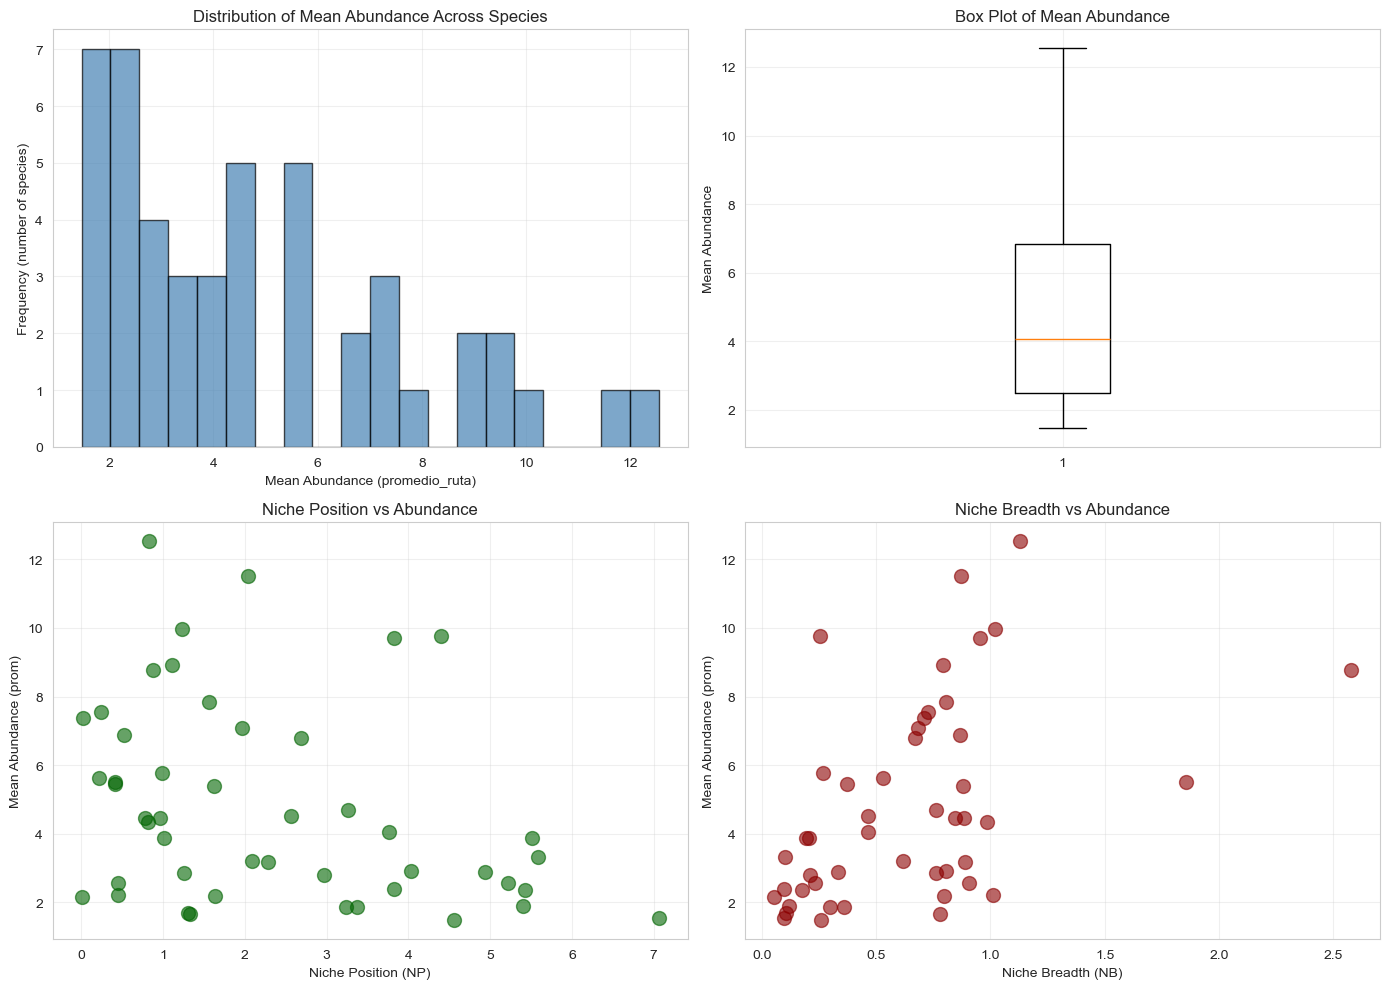


ABUNDANCE SUMMARY (per species)
Mean abundance across species: 4.814
Std dev: 2.903
Min: 1.473
Max: 12.541

Number of species: 47
Total records: 47786


In [6]:
# VISUALIZE: ABUNDANCE BY SPECIES + RELATIONSHIP WITH NICHE
# Calculate abundance statistics per species first

# Get the abundance column (promedio_ruta)
abundance_col = 'promedio_ruta'

# Group by species and calculate statistics
species_abundance = abundance_db.groupby('Scientific_name')[abundance_col].agg([
    'mean', 'std', 'min', 'max', 'count'
]).reset_index()

species_abundance.columns = ['Scientific_name', 'mean_abundance', 'sd_abundance', 'min_abundance', 'max_abundance', 'n_records']

print("\nAbundance statistics PER SPECIES:")
print(species_abundance.head(10))

# Now merge with PGLS data to see relationship with NP and NB
# Find species column in input_pgls
species_col_pgls = [col for col in input_pgls.columns if 'NOMBRE' in col or 'spp' in col.upper()]

# Plot 1: Mean abundance distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of mean abundance
axes[0,0].hist(species_abundance['mean_abundance'], bins=20, 
               color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].set_xlabel('Mean Abundance (promedio_ruta)')
axes[0,0].set_ylabel('Frequency (number of species)')
axes[0,0].set_title('Distribution of Mean Abundance Across Species')
axes[0,0].grid(True, alpha=0.3)

# Box plot
axes[0,1].boxplot(species_abundance['mean_abundance'], vert=True)
axes[0,1].set_ylabel('Mean Abundance')
axes[0,1].set_title('Box Plot of Mean Abundance')
axes[0,1].grid(True, alpha=0.3)

# Scatter: NP vs Mean Abundance (if NP column exists)
if 'NP' in input_pgls.columns:
    axes[1,0].scatter(input_pgls['NP'], input_pgls['prom'], 
                      s=100, alpha=0.6, color='darkgreen')
    axes[1,0].set_xlabel('Niche Position (NP)')
    axes[1,0].set_ylabel('Mean Abundance (prom)')
    axes[1,0].set_title('Niche Position vs Abundance')
    axes[1,0].grid(True, alpha=0.3)

# Scatter: NB vs Mean Abundance
if 'NB' in input_pgls.columns:
    axes[1,1].scatter(input_pgls['NB'], input_pgls['prom'], 
                      s=100, alpha=0.6, color='darkred')
    axes[1,1].set_xlabel('Niche Breadth (NB)')
    axes[1,1].set_ylabel('Mean Abundance (prom)')
    axes[1,1].set_title('Niche Breadth vs Abundance')
    axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print("ABUNDANCE SUMMARY (per species)")
print(f"{'='*60}")
print(f"Mean abundance across species: {species_abundance['mean_abundance'].mean():.3f}")
print(f"Std dev: {species_abundance['mean_abundance'].std():.3f}")
print(f"Min: {species_abundance['mean_abundance'].min():.3f}")
print(f"Max: {species_abundance['mean_abundance'].max():.3f}")
print(f"\nNumber of species: {len(species_abundance)}")
print(f"Total records: {species_abundance['n_records'].sum()}")

In [7]:
# VISUALIZE TOP 20 SPECIES BY PRESENCE RECORDS

species_cols = [col for col in presence_record.columns 
                if 'specie' in col.lower() or 'name' in col.lower()]

if species_cols:
    species_col = species_cols[0]
    species_counts = presence_record[species_col].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    species_counts.head(20).plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Number of Presence Records')
    ax.set_ylabel('Species')
    ax.set_title('Top 20 Species by Number of Presence Records')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal unique species: {presence_record[species_col].nunique()}")
    print(f"Total presence records: {len(presence_record)}")

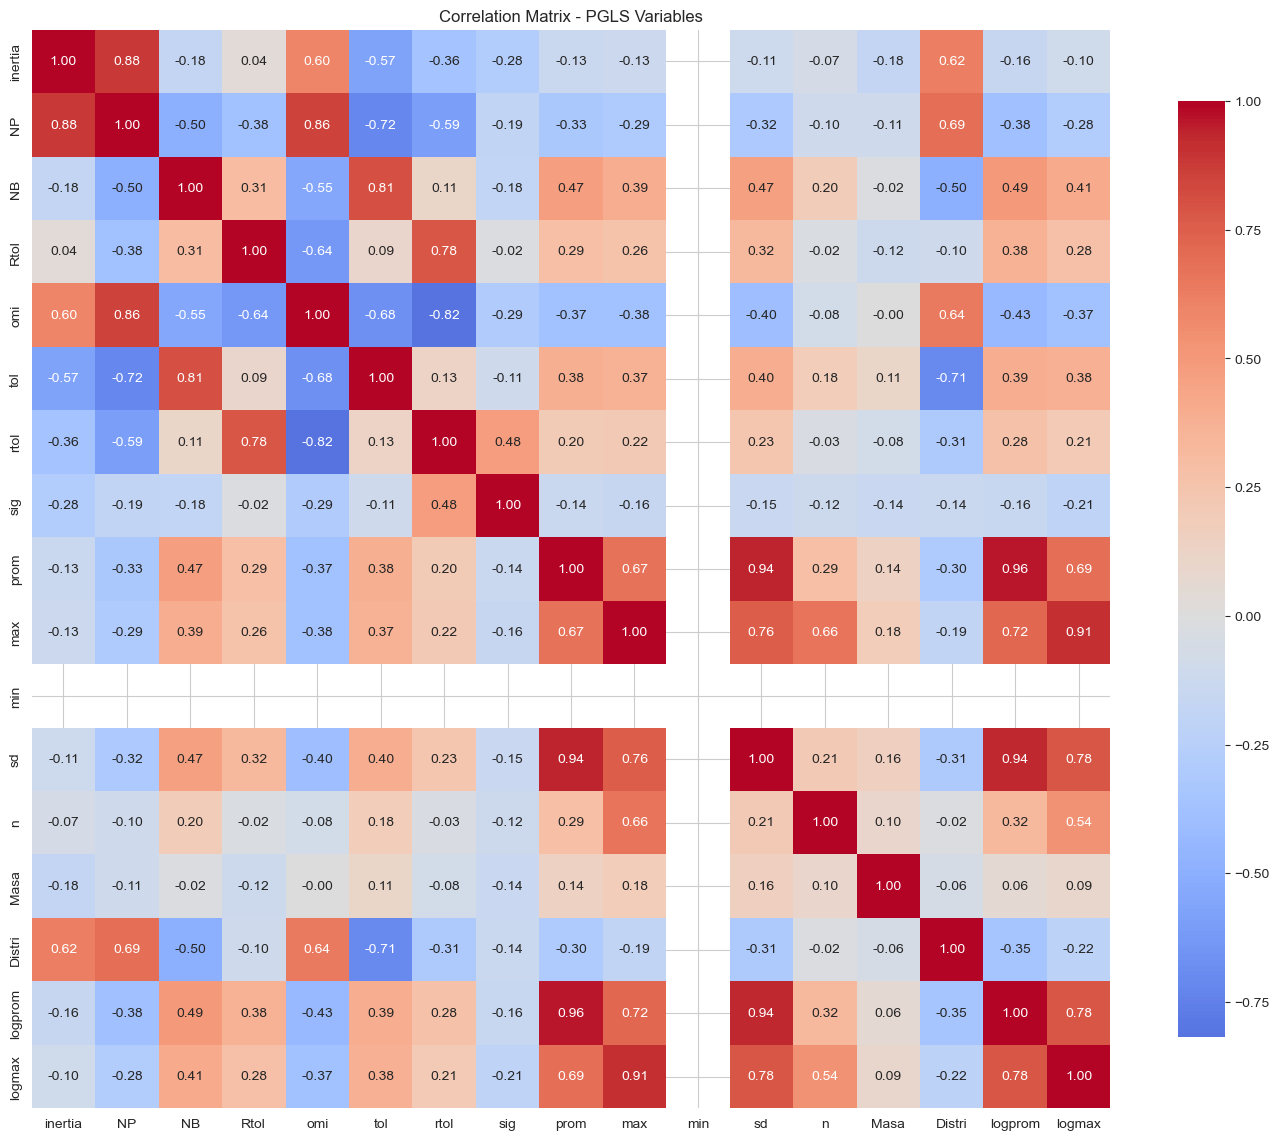


Variables in correlation matrix: ['inertia', 'NP', 'NB', 'Rtol', 'omi', 'tol', 'rtol', 'sig', 'prom', 'max', 'min', 'sd', 'n', 'Masa', 'Distri', 'logprom', 'logmax']


In [8]:
# CORRELATION MATRIX - PGLS VARIABLES

numeric_cols = input_pgls.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    corr_matrix = input_pgls[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title('Correlation Matrix - PGLS Variables')
    plt.tight_layout()
    plt.show()
    
    print(f"\nVariables in correlation matrix: {list(numeric_cols)}")